In [1]:
import feedparser
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import json
import time
import os
import smtplib
import subprocess
subprocess.run(["pip", "install", "python-dotenv"])
from datetime import datetime
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_squared_error, r2_score,
                             silhouette_score, silhouette_samples)
from sklearn.decomposition import PCA
 
print(" Libraries loaded successfully.")

 Libraries loaded successfully.


In [2]:
print("\n" + "=" * 60)
print("STEP 1: Extracting ANSSI RSS Feeds")
print("=" * 60)
 
REQUEST_DELAY = 2   # délai obligatoire entre requêtes (cf. consigne)
 
#  URLs distinctes pour avis et alerte
RSS_FEEDS = {
    'avis':   'https://www.cert.ssi.gouv.fr/avis/feed/',
    'alerte': 'https://www.cert.ssi.gouv.fr/alerte/feed/'
}
 
 
def extract_bulletin_id(link):
    """Extrait l'identifiant CERTFR depuis l'URL du bulletin."""
    if not link or link == 'N/A':
        return 'N/A'
    try:
        parts = link.rstrip('/').split('/')
        return parts[-1] if parts else 'N/A'
    except Exception:
        return 'N/A'
 
 
def parse_date_safe(date_string):
    """
    Parse une date de façon sécurisée.
    Retourne None si la chaîne est absente ou non parseable.
    """
    if not date_string or date_string in ('N/A', 'None', ''):
        return None
    try:
        return pd.to_datetime(date_string)
    except Exception:
        return None
 
 
def fetch_rss_feed(url, feed_type):
    """
     Gestion réseau : timeout + exception RequestException + boFeed vide.
    feedparser ne lève pas d'exception sur 404 : on vérifie le status.
    """
    print(f"  Fetching {feed_type.upper()} feed: {url}")
    try:
        # feedparser gère lui-même la requête HTTP ; on passe un timeout via requests
        response = requests.get(url, timeout=15)
        response.raise_for_status()   # lève HTTPError si status >= 400
        rss_data = feedparser.parse(response.text)
    except requests.exceptions.Timeout:
        print(f"    Timeout fetching {feed_type} feed — skipping")
        return []
    except requests.exceptions.HTTPError as e:
        print(f"    HTTP error {e} for {feed_type} feed — skipping")
        return []
    except requests.exceptions.RequestException as e:
        print(f"    Network error for {feed_type} feed: {e} — skipping")
        return []
    except Exception as e:
        print(f"    Unexpected error fetching {feed_type}: {e} — skipping")
        return []
 
    if not rss_data.entries:
        print(f"    No entries found for {feed_type}")
        return []
 
    entries = []
    for entry in rss_data.entries:
        try:
            bulletin_info = {
                'bulletin_id':      extract_bulletin_id(entry.get('link', 'N/A')),
                'bulletin_title':   entry.get('title', 'N/A'),
                'description':      re.sub(r'<[^>]+>|\s+', ' ',
                                           entry.get('description', 'N/A')).strip(),
                'publication_date': parse_date_safe(entry.get('published')),
                'bulletin_link':    entry.get('link', 'N/A'),
                'bulletin_type':    feed_type
            }
            entries.append(bulletin_info)
        except Exception as e:
            print(f"    Error parsing entry: {e}")
            continue
 
    print(f"   Fetched {len(entries)} {feed_type}(s)")
    return entries
 
 
def fetch_all_bulletins():
    all_entries = []
    for feed_type, url in RSS_FEEDS.items():
        time.sleep(REQUEST_DELAY)    # rate limiting obligatoire
        all_entries.extend(fetch_rss_feed(url, feed_type))
 
    if not all_entries:
        print("    No bulletins fetched. Check network or RSS URLs.")
        return pd.DataFrame()
 
    df_rss = pd.DataFrame(all_entries)
    if 'publication_date' in df_rss.columns and not df_rss.empty:
        df_rss = df_rss.sort_values('publication_date', ascending=False)
 
    print(f"\n SUMMARY: {len(df_rss)} bulletins fetched")
    print(f"   - Avis   : {len(df_rss[df_rss['bulletin_type'] == 'avis'])}")
    print(f"   - Alertes: {len(df_rss[df_rss['bulletin_type'] == 'alerte'])}")
    return df_rss
 
 
bulletin_df = fetch_all_bulletins()
if not bulletin_df.empty:
    print("\nFirst 5 records:\n", bulletin_df.head())
    os.makedirs('../data/raw/rss_cache', exist_ok=True)
    bulletin_df.to_csv('../data/raw/rss_cache/rss_bulletins.csv', index=False, encoding='utf-8')
    print(" RSS data saved to: ../data/raw/rss_cache/rss_bulletins.csv")


STEP 1: Extracting ANSSI RSS Feeds
  Fetching AVIS feed: https://www.cert.ssi.gouv.fr/avis/feed/
   Fetched 40 avis(s)
  Fetching ALERTE feed: https://www.cert.ssi.gouv.fr/alerte/feed/
   Fetched 40 alerte(s)

 SUMMARY: 80 bulletins fetched
   - Avis   : 40
   - Alertes: 40

First 5 records:
              bulletin_id                                     bulletin_title  \
39  CERTFR-2026-AVI-0753  Multiples vulnérabilités dans Microsoft Azure ...   
38  CERTFR-2026-AVI-0752  Multiples vulnérabilités dans les produits Mat...   
37  CERTFR-2026-AVI-0751        Vulnérabilité dans Spring AI (15 juin 2026)   
36  CERTFR-2026-AVI-0750  Vulnérabilité dans les produits HPE Aruba Netw...   
30  CERTFR-2026-AVI-0744  Multiples vulnérabilités dans les produits Spr...   

                                          description  \
39  De multiples vulnérabilités ont été découverte...   
38  De multiples vulnérabilités ont été découverte...   
37  Une vulnérabilité a été découverte dans Spring...   
36

In [3]:
print("\n" + "=" * 60)
print("STEP 3: Extracting CVEs from Local Bulletin JSON Files")
print("=" * 60)
 
BASE_DATA_PATH = "../data/raw/"
 
 
def load_json_file(file_path):
    """
     Gestion FileNotFoundError + JSONDecodeError + encodage.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except json.JSONDecodeError as e:
        raise json.JSONDecodeError(f"JSON parse error in {file_path}: {e.msg}",
                                   e.doc, e.pos)
    except UnicodeDecodeError:
        # Fallback latin-1
        with open(file_path, 'r', encoding='latin-1') as f:
            return json.load(f)
 
 
def extract_cves_from_bulletin(data):
    """
     Double extraction : champ 'cves' + regex sur tout le JSON.
     set() pour dédupliquer. Ne plante pas si le champ est absent.
    """
    cves = set()
 
    # Méthode 1 : champ structuré 'cves'
    try:
        if "cves" in data and isinstance(data["cves"], list):
            for cve_item in data["cves"]:
                if isinstance(cve_item, dict) and "name" in cve_item:
                    cves.add(cve_item["name"])
                elif isinstance(cve_item, str) and cve_item.startswith("CVE-"):
                    cves.add(cve_item)
    except Exception as e:
        print(f"      Error parsing 'cves' field: {e}")
 
    # Méthode 2 : regex sur la représentation texte complète du JSON
    #  Ne plante jamais — re.findall retourne [] si rien trouvé
    try:
        cve_pattern = r"CVE-\d{4}-\d{4,7}"
        text_cves = set(re.findall(cve_pattern, json.dumps(data)))
        cves.update(text_cves)
    except Exception as e:
        print(f"      Error in regex CVE extraction: {e}")
 
    return list(cves)
 
 
def process_bulletin_files(bulletin_type):
    """
    Traite tous les fichiers JSON d'un type de bulletin (avis/alertes).
     Gestion FileNotFoundError, JSONDecodeError, encodage.
     Cohérence dossier local / URL ANSSI.
    """
    # Nom du dossier local
    folder_map = {
        'avis':    'Avis',
        'alerte':  'Alertes',
        'alertes': 'Alertes'
    }
    folder_name = folder_map.get(bulletin_type, bulletin_type)
 
    # Segment URL ANSSI réel (alertes → /alerte/ sans 's')
    url_segment = 'avis' if bulletin_type == 'avis' else 'alerte'
 
    folder_path = os.path.join(BASE_DATA_PATH, folder_name)
 
    if not os.path.exists(folder_path):
        print(f"    Folder not found: {folder_path} — skipping")
        return []
 
    json_files = [f for f in os.listdir(folder_path)
                  if not f.endswith('.csv') and f != 'rss_cache'
                  and os.path.isfile(os.path.join(folder_path, f))]
 
    print(f"  Processing {len(json_files)} {bulletin_type} files...")
 
    results = []
    errors = 0
 
    for filename in json_files:
        file_path = os.path.join(folder_path, filename)
 
        #  Gestion FileNotFoundError + JSONDecodeError
        try:
            data = load_json_file(file_path)
        except FileNotFoundError as e:
            print(f"      {e}")
            errors += 1
            continue
        except json.JSONDecodeError as e:
            print(f"      {e}")
            errors += 1
            continue
        except Exception as e:
            print(f"      Unexpected error reading {filename}: {e}")
            errors += 1
            continue
 
        if not data or not isinstance(data, dict):
            continue
 
        bulletin_id = filename.replace('.json', '')
        title       = data.get('title', 'N/A') or 'N/A'
 
        #  Normalisation immédiate de la date en Step 3
        raw_date = (data.get('date') or data.get('published')
                    or data.get('publication_date'))
        try:
            publication_date = (pd.to_datetime(raw_date).strftime('%Y-%m-%d')
                                if raw_date else None)
        except Exception:
            publication_date = None    # None → dropna fonctionne dans Step 5
 
        #  URL ANSSI correcte (/alerte/ sans 's')
        bulletin_link = f"https://www.cert.ssi.gouv.fr/{url_segment}/{bulletin_id}/"
 
        cves = extract_cves_from_bulletin(data)
 
        if not cves:
            # Bulletin sans CVE identifié : on garde quand même une ligne
            results.append({
                'bulletin_id':       bulletin_id,
                'bulletin_title':    title,
                'bulletin_type':     bulletin_type,
                'publication_date':  publication_date,
                'bulletin_link':     bulletin_link,
                'cve_id':            'N/A',
                'cve_description':   'N/A',
                'cvss_score':        None,
                'base_severity':     None,
                'cwe_type':          'N/A',
                'epss_score':        None,
                'vendor':            'N/A',
                'product':           'N/A',
                'affected_versions': 'N/A'
            })
        else:
            #  Un bulletin → plusieurs CVE = plusieurs lignes (multi-CVE)
            for cve_id in cves:
                results.append({
                    'bulletin_id':       bulletin_id,
                    'bulletin_title':    title,
                    'bulletin_type':     bulletin_type,
                    'publication_date':  publication_date,
                    'bulletin_link':     bulletin_link,
                    'cve_id':            cve_id,
                    'cve_description':   'N/A',
                    'cvss_score':        None,
                    'base_severity':     None,
                    'cwe_type':          'N/A',
                    'epss_score':        None,
                    'vendor':            'N/A',
                    'product':           'N/A',
                    'affected_versions': 'N/A'
                })
            print(f"    {bulletin_id}: {len(cves)} CVE(s) found")
 
    print(f"   Done — {len(results)} rows, {errors} error(s)")
    return results
 
 
all_bulletins = []
for bt in ['avis', 'alertes']:
    all_bulletins.extend(process_bulletin_files(bt))
 
df_bulletins = pd.DataFrame(all_bulletins)
 
print(f"\n SUMMARY: {len(df_bulletins)} rows (bulletins × CVEs)")
if not df_bulletins.empty:
    print(f"  Unique bulletins: {df_bulletins['bulletin_id'].nunique()}")
    print(f"  Unique CVEs     : {df_bulletins['cve_id'].nunique()}")
    print(f"\nFirst 10 rows:\n{df_bulletins.head(10)}")
 
    os.makedirs('../data/processed', exist_ok=True)
    df_bulletins.to_csv('../data/processed/cve_extracted.csv', index=False, encoding='utf-8')
    print("\n Saved to: ../data/processed/cve_extracted.csv")
    print(df_bulletins['bulletin_type'].value_counts())
 


STEP 3: Extracting CVEs from Local Bulletin JSON Files
  Processing 4025 avis files...
    CERTFR-2023-AVI-0001: 1 CVE(s) found
    CERTFR-2023-AVI-0002: 4 CVE(s) found
    CERTFR-2023-AVI-0003: 59 CVE(s) found
    CERTFR-2023-AVI-0004: 2 CVE(s) found
    CERTFR-2023-AVI-0005: 1 CVE(s) found
    CERTFR-2023-AVI-0006: 5 CVE(s) found
    CERTFR-2023-AVI-0007: 7 CVE(s) found
    CERTFR-2023-AVI-0008: 6 CVE(s) found
    CERTFR-2023-AVI-0009: 1 CVE(s) found
    CERTFR-2023-AVI-0010: 10 CVE(s) found
    CERTFR-2023-AVI-0011: 5 CVE(s) found
    CERTFR-2023-AVI-0012: 15 CVE(s) found
    CERTFR-2023-AVI-0013: 10 CVE(s) found
    CERTFR-2023-AVI-0014: 7 CVE(s) found
    CERTFR-2023-AVI-0015: 24 CVE(s) found
    CERTFR-2023-AVI-0016: 15 CVE(s) found
    CERTFR-2023-AVI-0017: 3 CVE(s) found
    CERTFR-2023-AVI-0018: 1 CVE(s) found
    CERTFR-2023-AVI-0019: 12 CVE(s) found
    CERTFR-2023-AVI-0020: 14 CVE(s) found
    CERTFR-2023-AVI-0021: 9 CVE(s) found
    CERTFR-2023-AVI-0022: 67 CVE(s) found
 

In [4]:
import os
import json
import pandas as pd
import time
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 4: Enriching CVEs with MITRE and FIRST Data (LOCAL ONLY)")
print("=" * 60)

BASE_DATA_PATH = "../data/raw/"
REQUEST_DELAY = 0  # 不需要延迟，因为只读本地文件

def load_json_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        return {}

# ---------- helpers d'extraction MITRE ----------

def extract_cvss_score(cna_data):
    try:
        metrics = cna_data.get("metrics", [])
        if not isinstance(metrics, list):
            return None
        for metric in metrics:
            for version in ("cvssV3_1", "cvssV3_0", "cvssV2_0", "cvssV2"):
                if version in metric:
                    score = metric[version].get("baseScore")
                    if score is not None:
                        return float(score)
    except Exception:
        pass
    return None

def extract_cwe(cna_data):
    try:
        problem_types = cna_data.get("problemTypes", [])
        if not problem_types or not isinstance(problem_types, list):
            return "N/A"
        descriptions = problem_types[0].get("descriptions", [])
        if not descriptions:
            return "N/A"
        cwe_id = descriptions[0].get("cweId", "N/A")
        return cwe_id if cwe_id else "N/A"
    except Exception:
        return "N/A"

def extract_description(cna_data):
    try:
        descriptions = cna_data.get("descriptions", [])
        if descriptions and isinstance(descriptions, list):
            return descriptions[0].get("value", "N/A") or "N/A"
    except Exception:
        pass
    return "N/A"

def extract_affected_products(cna_data):
    vendors, products, versions_list = [], [], []
    try:
        affected = cna_data.get("affected", [])
        if not isinstance(affected, list):
            return "N/A", "N/A", "N/A"

        for item in affected:
            if not isinstance(item, dict):
                continue
            vendors.append(str(item.get("vendor", "N/A") or "N/A"))
            products.append(str(item.get("product", "N/A") or "N/A"))

            vers = [
                str(v.get("version", "unknown"))
                for v in item.get("versions", [])
                if isinstance(v, dict) and v.get("status") == "affected"
            ]
            versions_list.append(", ".join(vers) if vers else "N/A")

    except Exception:
        pass

    return (
        " | ".join(set(vendors))   if vendors       else "N/A",
        " | ".join(set(products))  if products      else "N/A",
        " | ".join(versions_list)  if versions_list else "N/A"
    )

def _default_mitre():
    return {'description': 'N/A', 'cvss_score': None, 'cwe_type': 'N/A',
            'vendor': 'N/A', 'product': 'N/A', 'affected_versions': 'N/A'}

def enrich_from_mitre_local(cve_id):
    """Enrichissement depuis le cache local (dossier mitre/)."""
    mitre_path = os.path.join(BASE_DATA_PATH, "mitre", cve_id)
    if not os.path.exists(mitre_path):
        return _default_mitre()  # 直接返回默认值，不调用API

    try:
        data = load_json_file(mitre_path)
    except Exception:
        return _default_mitre()

    if not data or not isinstance(data, dict):
        return _default_mitre()

    cna_data = data.get("containers", {}).get("cna", {})
    vendor, product, affected_versions = extract_affected_products(cna_data)

    return {
        'description': extract_description(cna_data),
        'cvss_score': extract_cvss_score(cna_data),
        'cwe_type': extract_cwe(cna_data),
        'vendor': vendor,
        'product': product,
        'affected_versions': affected_versions
    }

def enrich_from_first_local(cve_id):
    """Enrichissement EPSS depuis cache local (dossier first/)."""
    first_path = os.path.join(BASE_DATA_PATH, "first", cve_id)
    if not os.path.exists(first_path):
        return None

    try:
        data = load_json_file(first_path)
    except Exception:
        return None

    if not data:
        return None

    epss_data = data.get("data", [])
    if epss_data and isinstance(epss_data, list):
        try:
            return float(epss_data[0].get("epss", 0))
        except (TypeError, ValueError):
            return None
    return None

def get_severity(cvss_score):
    if cvss_score is None or pd.isna(cvss_score):
        return 'N/A'
    elif cvss_score >= 9.0:
        return 'Critical'
    elif cvss_score >= 7.0:
        return 'High'
    elif cvss_score >= 4.0:
        return 'Medium'
    else:
        return 'Low'

# --- Chargement et enrichissement ---
print("\nLoading CVE data from Step 3...")
try:
    df = pd.read_csv('../data/processed/cve_extracted.csv')
    print(f"Loaded {len(df)} rows, {df['cve_id'].nunique()} unique CVEs")
except FileNotFoundError:
    print("cve_extracted.csv not found — run Step 3 first.")
    raise

unique_cves = [
    c for c in df['cve_id'].unique()
    if isinstance(c, str) and c.startswith('CVE-')
]
print(f"\nEnriching {len(unique_cves)} unique CVEs from LOCAL files only (no API)...")

mitre_cache = {}
first_cache = {}

for i, cve_id in enumerate(unique_cves, 1):
    if not isinstance(cve_id, str):
        continue
    mitre_cache[cve_id] = enrich_from_mitre_local(cve_id)
    first_cache[cve_id] = enrich_from_first_local(cve_id)
    if i % 5000 == 0:
        print(f"  Progress: {i}/{len(unique_cves)}")

print("\nApplying enrichment (vectorized)...")
df['cve_description'] = df['cve_id'].map(
    lambda x: mitre_cache.get(x, _default_mitre()).get('description', 'N/A'))
df['cvss_score'] = pd.to_numeric(
    df['cve_id'].map(lambda x: mitre_cache.get(x, _default_mitre()).get('cvss_score')),
    errors='coerce')
df['cwe_type'] = df['cve_id'].map(
    lambda x: mitre_cache.get(x, _default_mitre()).get('cwe_type', 'N/A'))
df['vendor'] = df['cve_id'].map(
    lambda x: mitre_cache.get(x, _default_mitre()).get('vendor', 'N/A'))
df['product'] = df['cve_id'].map(
    lambda x: mitre_cache.get(x, _default_mitre()).get('product', 'N/A'))
df['affected_versions'] = df['cve_id'].map(
    lambda x: mitre_cache.get(x, _default_mitre()).get('affected_versions', 'N/A'))
df['epss_score'] = pd.to_numeric(
    df['cve_id'].map(lambda x: first_cache.get(x)), errors='coerce')
df['base_severity'] = df['cvss_score'].map(get_severity)

print("\n" + "=" * 50)
print("ENRICHMENT SUMMARY")
print("=" * 50)
n = len(df)
print(f"Total rows                : {n}")
print(f"Rows with CVSS            : {df['cvss_score'].notna().sum()} ({df['cvss_score'].notna().sum()/n*100:.1f}%)")
print(f"Rows with EPSS            : {df['epss_score'].notna().sum()} ({df['epss_score'].notna().sum()/n*100:.1f}%)")
print(f"Rows with CWE             : {(df['cwe_type']!='N/A').sum()} ({(df['cwe_type']!='N/A').sum()/n*100:.1f}%)")
print(f"Unique products affected  : {df[df['product']!='N/A']['product'].nunique()}")
print(f"Unique vendors affected   : {df[df['vendor']!='N/A']['vendor'].nunique()}")
print("\nSeverity distribution:")
for sev, cnt in df['base_severity'].value_counts().items():
    print(f"  {sev}: {cnt} ({cnt/n*100:.1f}%)")

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/consolidated_cve_data.csv', index=False, encoding='utf-8')
print(f"\nSaved to: ../data/processed/consolidated_cve_data.csv")
print(f"Shape: {df.shape} | Columns: {list(df.columns)}")
print("\nFirst 5 rows preview:")
print(df.head())

STEP 4: Enriching CVEs with MITRE and FIRST Data (LOCAL ONLY)

Loading CVE data from Step 3...
Loaded 126124 rows, 37287 unique CVEs

Enriching 37287 unique CVEs from LOCAL files only (no API)...
  Progress: 5000/37287
  Progress: 10000/37287
  Progress: 15000/37287
  Progress: 20000/37287
  Progress: 25000/37287
  Progress: 30000/37287
  Progress: 35000/37287

Applying enrichment (vectorized)...

ENRICHMENT SUMMARY
Total rows                : 126124
Rows with CVSS            : 27107 (21.5%)
Rows with EPSS            : 124828 (99.0%)
Rows with CWE             : 28545 (22.6%)
Unique products affected  : 4634
Unique vendors affected   : 732

Severity distribution:
  N/A: 99017 (78.5%)
  Medium: 11928 (9.5%)
  High: 11812 (9.4%)
  Low: 2026 (1.6%)
  Critical: 1341 (1.1%)

Saved to: ../data/processed/consolidated_cve_data.csv
Shape: (126124, 14) | Columns: ['bulletin_id', 'bulletin_title', 'bulletin_type', 'publication_date', 'bulletin_link', 'cve_id', 'cve_description', 'cvss_score', 'bas

STEP 5: Data Visualization and Analysis
Loaded 126124 rows, 37287 unique CVEs
Valid publication_date: 0/126124
CVSS range: 0.0 – 10.0
EPSS range: 0.0000 – 0.9452

1. CVSS Score Distribution Histogram


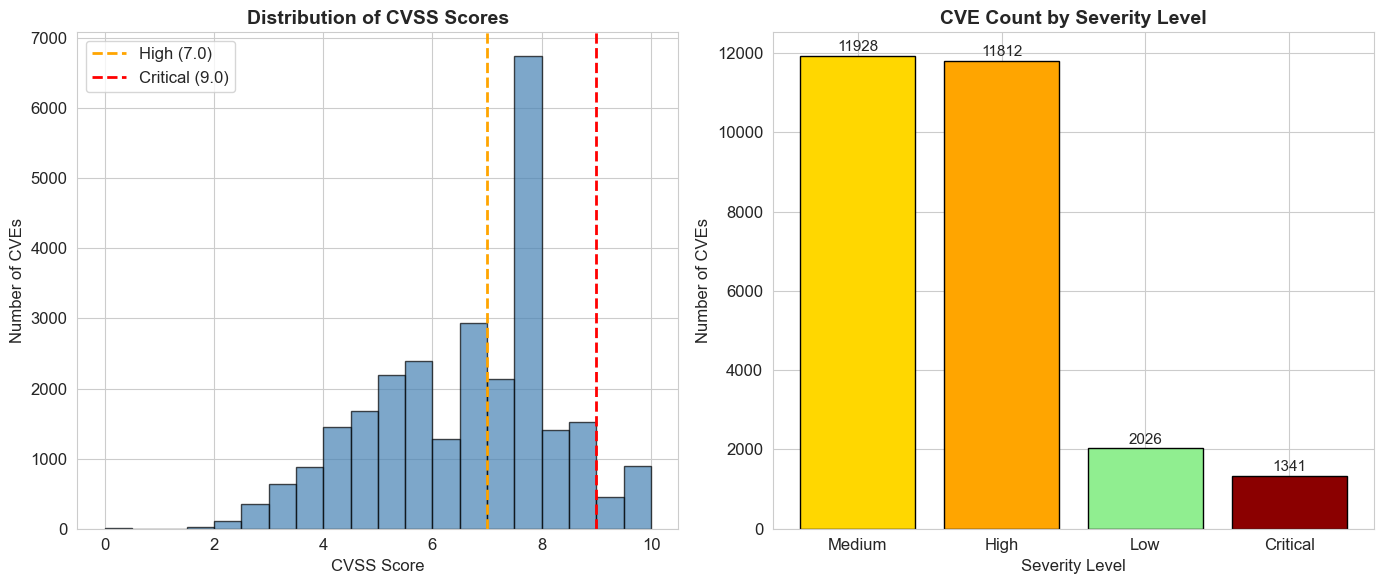

Saved: cvss_distribution.png

2. Top 10 CWE Types Pie Chart


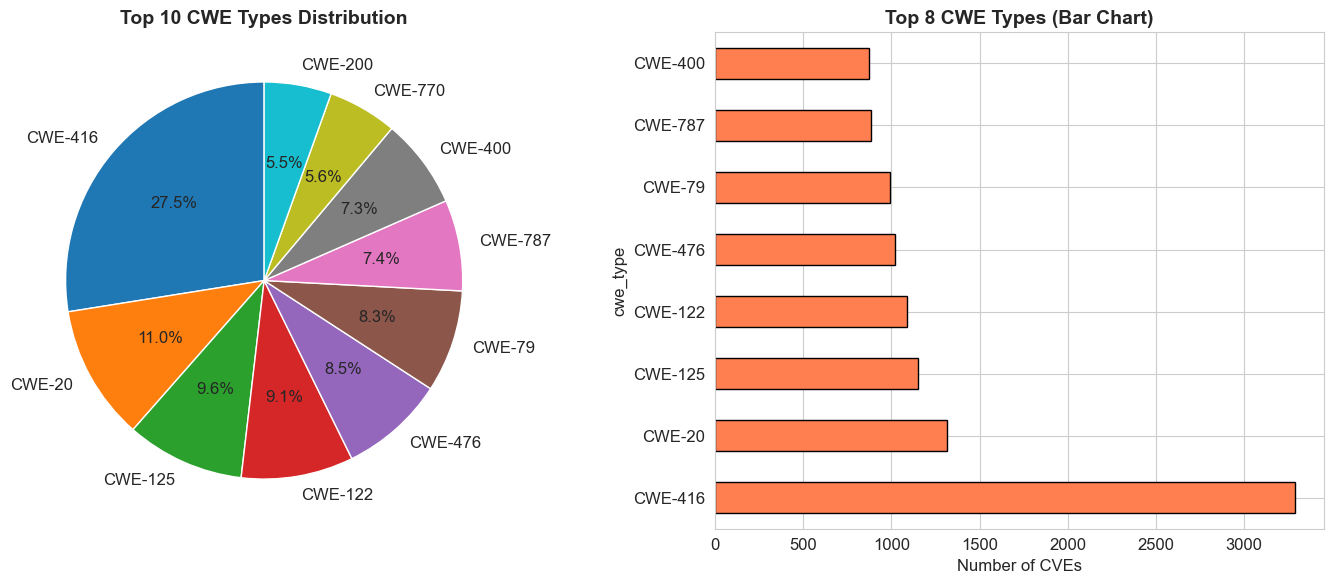

Saved: cwe_distribution.png

3. CVSS vs EPSS Scatter Plot


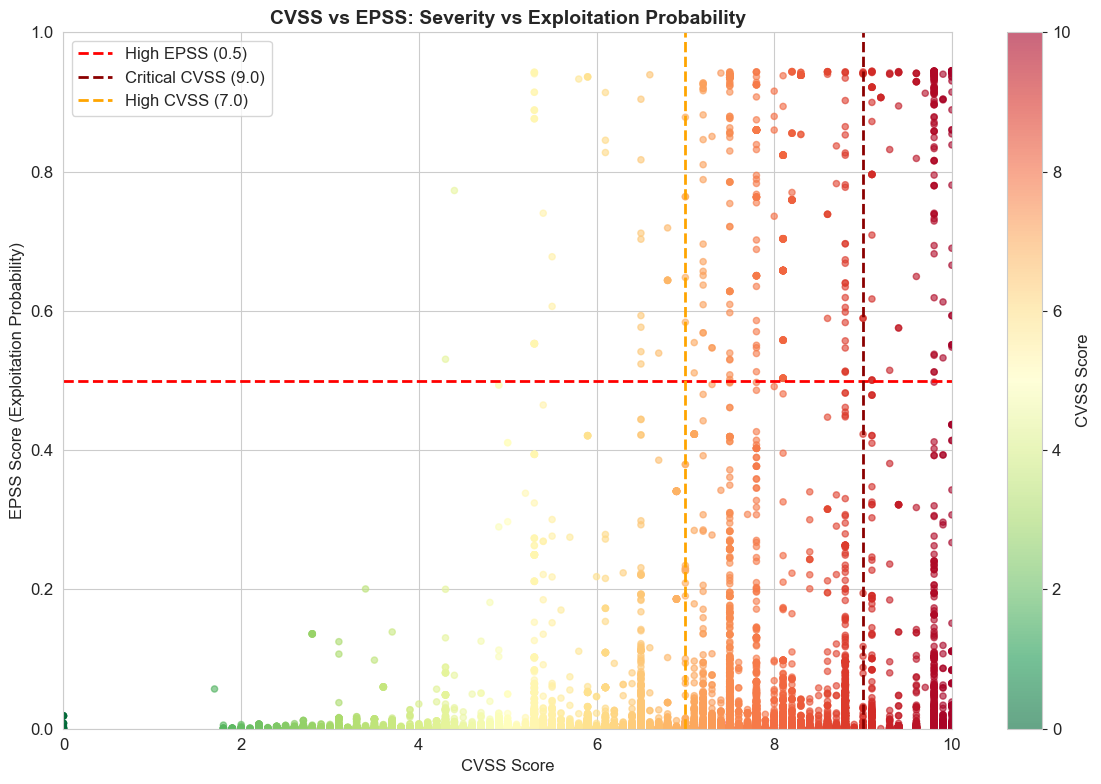

Saved: cvss_vs_epss_scatter.png

4. EPSS Score Distribution


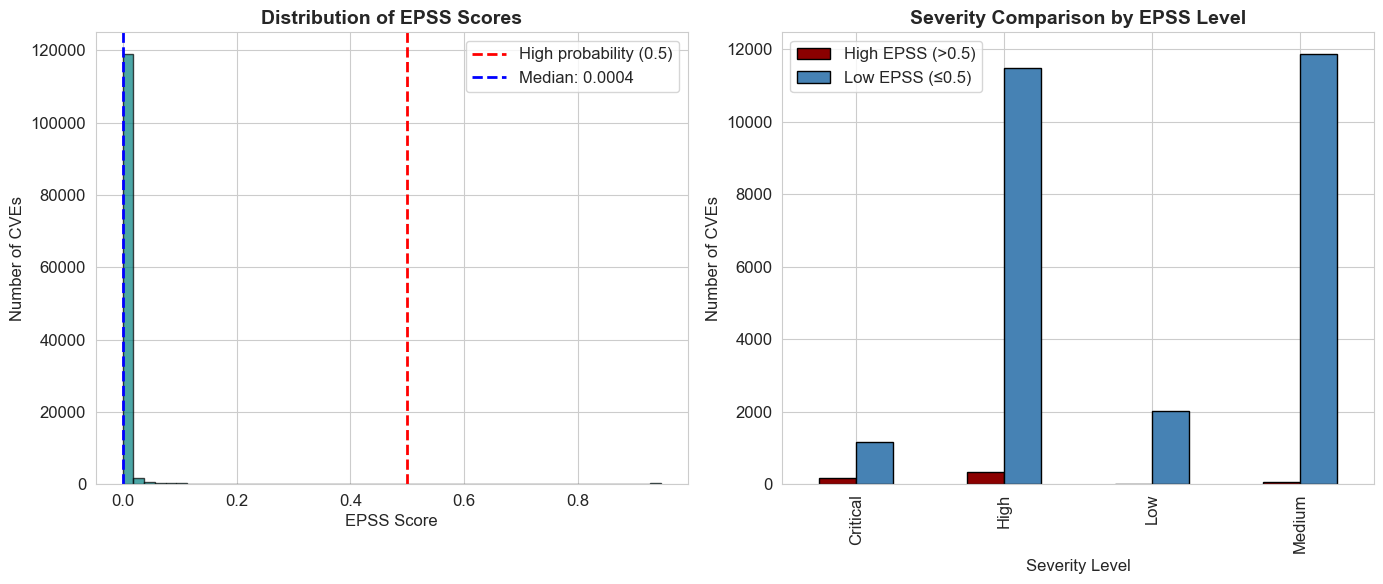

Saved: epss_distribution.png

5. Top 10 Most Affected Vendors


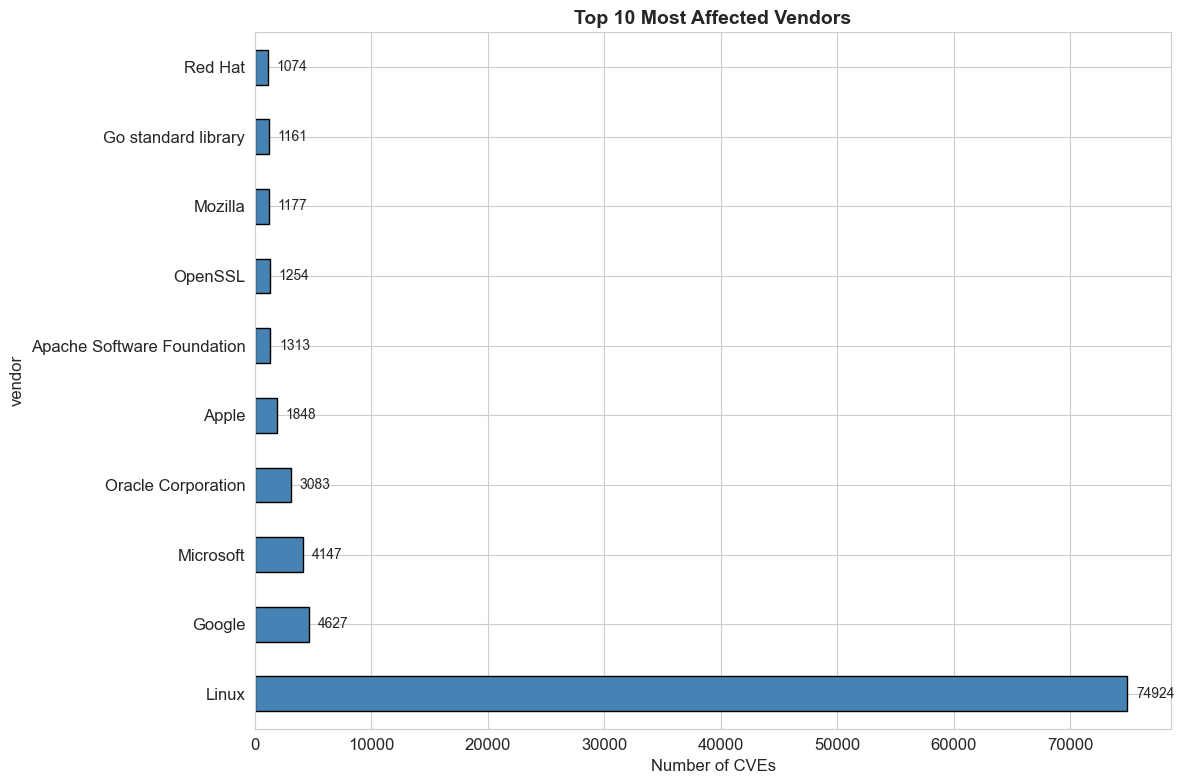

Saved: top_vendors.png

6. Top 10 Most Affected Products


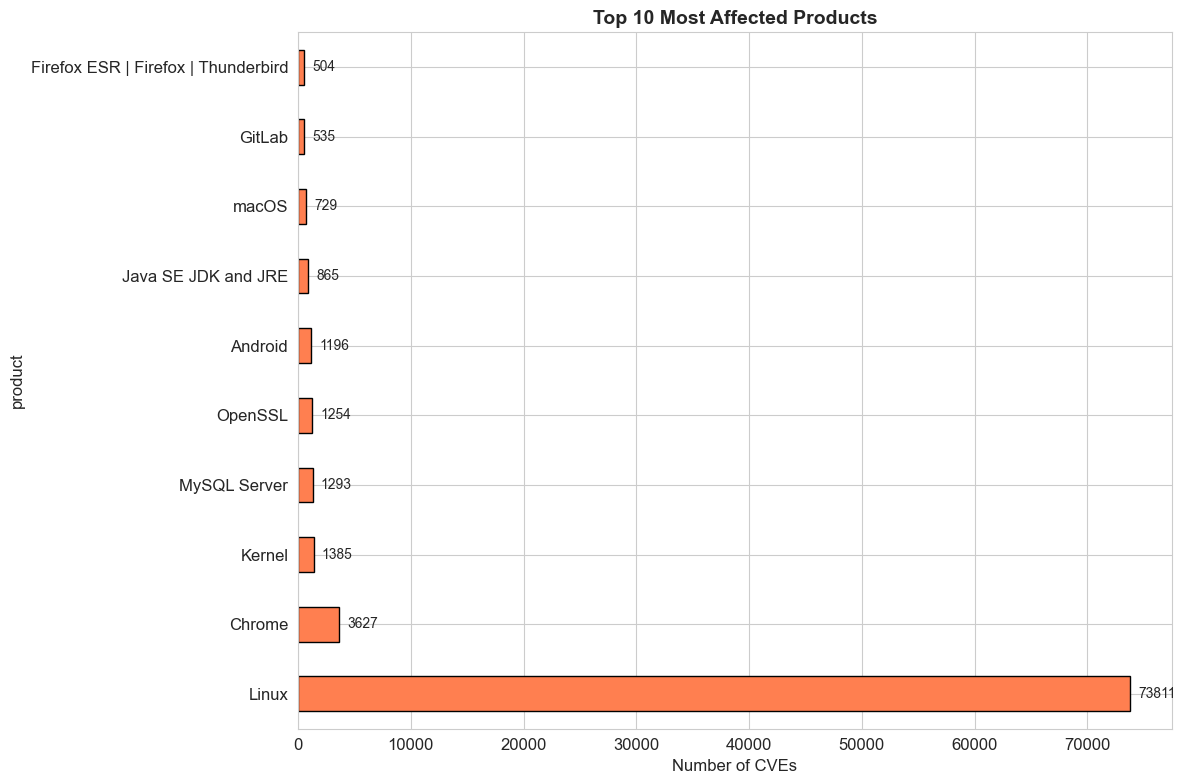

Saved: top_products.png

7. CVSS Boxplot by Top Vendors


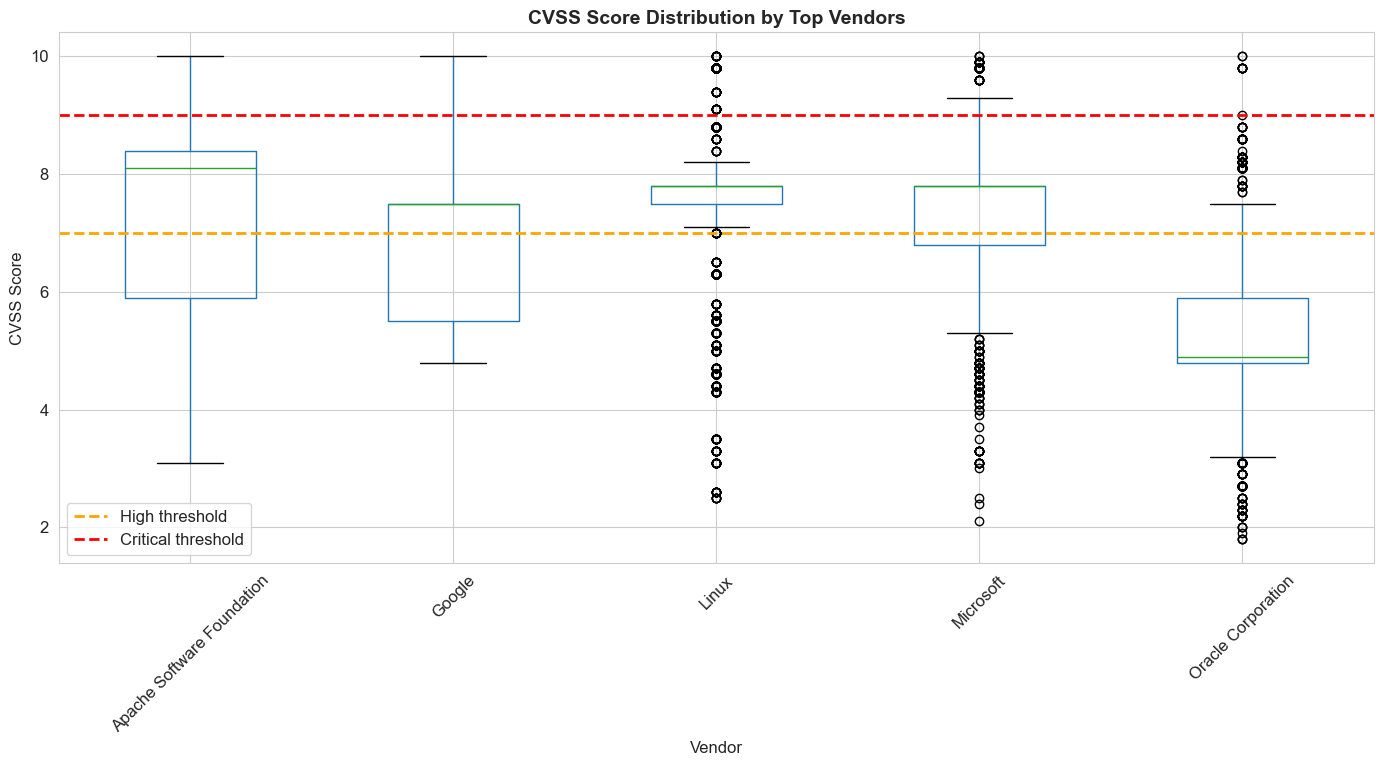

Saved: cvss_boxplot_by_vendor.png

8. Correlation Heatmap


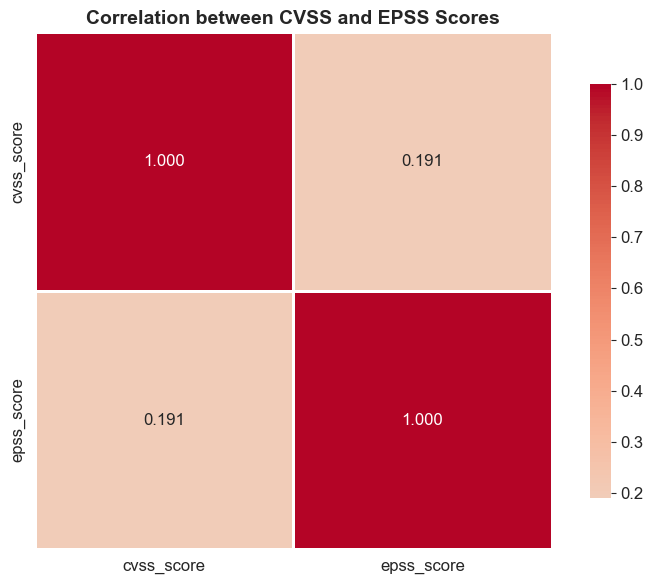

Correlation coefficient: 0.1910
Saved: correlation_heatmap.png

9. Bulletin Type Comparison (Avis vs Alertes)


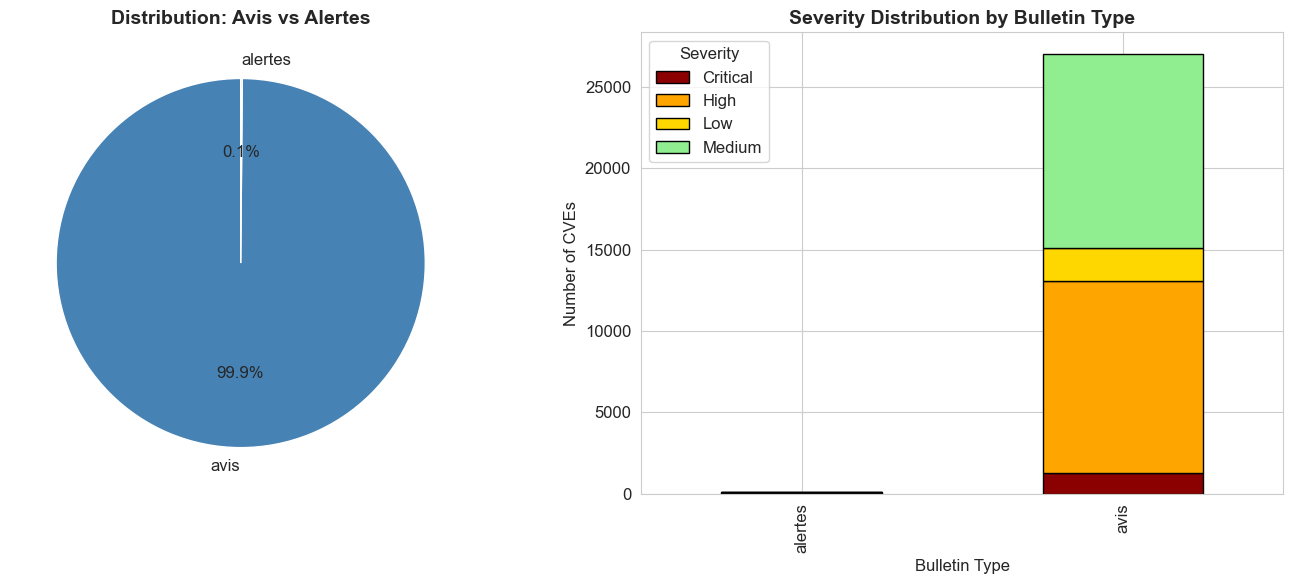

Saved: bulletin_type_comparison.png

11. Interactive Scatter Plot with Plotly
Saved: interactive_scatter.html (open in browser)

12. Statistical Summary
STATISTICAL SUMMARY

Total CVEs analyzed:      37,287
Total bulletin-CVE pairs: 126,124

CVSS Score Statistics:
  Mean:   6.57
  Median: 6.80
  Std:    1.66

EPSS Score Statistics:
  Mean:   0.0129
  Median: 0.0004
  CVEs with EPSS > 0.5: 1,288 (1.0%)

Critical CVEs (CVSS ≥ 9.0): 1,341 (4.9%)
High Risk CVEs (EPSS>0.5 AND CVSS≥7.0): 507

All visualizations saved to: ../outputs/plots/


In [5]:
print("=" * 60)
print("STEP 5: Data Visualization and Analysis")
print("=" * 60)
 
df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')
 
# FIX (date) : vérification du parsing avant les tracés
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
valid_dates = df['publication_date'].notna().sum()
print(f"Loaded {len(df)} rows, {df['cve_id'].nunique()} unique CVEs")
print(f"Valid publication_date: {valid_dates}/{len(df)}")
if valid_dates == 0:
    print("WARNING: No valid dates found — check JSON date fields in Step 3.")
print(f"CVSS range: {df['cvss_score'].min():.1f} – {df['cvss_score'].max():.1f}")
print(f"EPSS range: {df['epss_score'].min():.4f} – {df['epss_score'].max():.4f}\n")
 
os.makedirs('../outputs/plots', exist_ok=True)
 
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
 
 
# --- 1. Distribution des scores CVSS ---
print("1. CVSS Score Distribution Histogram")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cvss_clean = df['cvss_score'].dropna()
axes[0].hist(cvss_clean, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('CVSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of CVSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=7.0, color='orange', linestyle='--', linewidth=2, label='High (7.0)')
axes[0].axvline(x=9.0, color='red',    linestyle='--', linewidth=2, label='Critical (9.0)')
axes[0].legend()
 
severity_counts = df['base_severity'].value_counts()
colors_sev = {'Critical': 'darkred', 'High': 'orange',
              'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'}
sev_colors = [colors_sev.get(s, 'gray') for s in severity_counts.index]
axes[1].bar(severity_counts.index, severity_counts.values, color=sev_colors, edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('CVE Count by Severity Level', fontsize=14, fontweight='bold')
 
# FIX #8 : décalage dynamique basé sur les données, non plus hardcodé
max_val = severity_counts.max() if not severity_counts.empty else 1
offset = max_val * 0.01
for i, (idx, val) in enumerate(zip(severity_counts.index, severity_counts.values)):
    axes[1].text(i, val + offset, str(val), ha='center', fontsize=11)
 
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_distribution.png\n")
 
 
# --- 2. Top 10 CWE Types ---
print("2. Top 10 CWE Types Pie Chart")
cwe_counts = df[df['cwe_type'] != 'N/A']['cwe_type'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(cwe_counts.values, labels=cwe_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Top 10 CWE Types Distribution', fontsize=14, fontweight='bold')
cwe_counts.head(8).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Number of CVEs')
axes[1].set_title('Top 8 CWE Types (Bar Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/cwe_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cwe_distribution.png\n")
 
 
# --- 3. Scatter CVSS vs EPSS ---
print("3. CVSS vs EPSS Scatter Plot")
df_scatter = df.dropna(subset=['cvss_score', 'epss_score']).copy()
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(df_scatter['cvss_score'], df_scatter['epss_score'],
                     c=df_scatter['cvss_score'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax.set_xlabel('CVSS Score', fontsize=12)
ax.set_ylabel('EPSS Score (Exploitation Probability)', fontsize=12)
ax.set_title('CVSS vs EPSS: Severity vs Exploitation Probability',
             fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red',    linestyle='--', linewidth=2, label='High EPSS (0.5)')
ax.axvline(x=9.0, color='darkred', linestyle='--', linewidth=2, label='Critical CVSS (9.0)')
ax.axvline(x=7.0, color='orange',  linestyle='--', linewidth=2, label='High CVSS (7.0)')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.colorbar(scatter, label='CVSS Score')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_vs_epss_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_vs_epss_scatter.png\n")
 
 
# --- 4. Distribution des scores EPSS ---
print("4. EPSS Score Distribution")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
epss_clean = df['epss_score'].dropna()
axes[0].hist(epss_clean, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('EPSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of EPSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=0.5, color='red',  linestyle='--', linewidth=2, label='High probability (0.5)')
axes[0].axvline(x=epss_clean.median(), color='blue', linestyle='--', linewidth=2,
                label=f'Median: {epss_clean.median():.4f}')
axes[0].legend()
 
high_epss = df[df['epss_score'] > 0.5]['base_severity'].value_counts()
low_epss  = df[df['epss_score'] <= 0.5]['base_severity'].value_counts()
epss_compare = pd.DataFrame({'High EPSS (>0.5)': high_epss,
                              'Low EPSS (≤0.5)':  low_epss}).fillna(0)
epss_compare.plot(kind='bar', ax=axes[1],
                  color=['darkred', 'steelblue'], edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('Severity Comparison by EPSS Level', fontsize=14, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: epss_distribution.png\n")
 
 
# --- 5. Top 10 Vendors ---
print("5. Top 10 Most Affected Vendors")
vendor_counts = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
vendor_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Vendors', fontsize=14, fontweight='bold')
 
# FIX #8 : offset dynamique
max_v = vendor_counts.max() if not vendor_counts.empty else 1
offset_v = max_v * 0.01
for i, (idx, val) in enumerate(zip(vendor_counts.index, vendor_counts.values)):
    ax.text(val + offset_v, i, str(val), va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('../outputs/plots/top_vendors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_vendors.png\n")
 
 
# --- 6. Top 10 Products ---
print("6. Top 10 Most Affected Products")
product_counts = df[df['product'] != 'N/A']['product'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
product_counts.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Products', fontsize=14, fontweight='bold')
 
# FIX #8 : offset dynamique
max_p = product_counts.max() if not product_counts.empty else 1
offset_p = max_p * 0.01
for i, (idx, val) in enumerate(zip(product_counts.index, product_counts.values)):
    ax.text(val + offset_p, i, str(val), va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('../outputs/plots/top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_products.png\n")
 
 
# --- 7. Boxplot CVSS par Vendor ---
print("7. CVSS Boxplot by Top Vendors")
top_vendors   = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(8).index
df_top_vendors = df[df['vendor'].isin(top_vendors)].dropna(subset=['cvss_score'])
fig, ax = plt.subplots(figsize=(14, 8))
df_top_vendors.boxplot(column='cvss_score', by='vendor', ax=ax, rot=45)
ax.set_xlabel('Vendor', fontsize=12)
ax.set_ylabel('CVSS Score', fontsize=12)
ax.set_title('CVSS Score Distribution by Top Vendors', fontsize=14, fontweight='bold')
ax.axhline(y=7.0, color='orange', linestyle='--', linewidth=2, label='High threshold')
ax.axhline(y=9.0, color='red',    linestyle='--', linewidth=2, label='Critical threshold')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_boxplot_by_vendor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_boxplot_by_vendor.png\n")
 
 
# --- 8. Heatmap de corrélation ---
print("8. Correlation Heatmap")
df_corr = df[['cvss_score', 'epss_score']].dropna()
correlation = df_corr.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.3f', linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation between CVSS and EPSS Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation coefficient: {correlation.iloc[0,1]:.4f}")
print("Saved: correlation_heatmap.png\n")
 
 
# --- 9. Avis vs Alertes ---
print("9. Bulletin Type Comparison (Avis vs Alertes)")
type_counts   = df['bulletin_type'].value_counts()
type_severity = pd.crosstab(df['bulletin_type'], df['base_severity'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
type_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                 colors=['steelblue', 'coral'], startangle=90)
axes[0].set_title('Distribution: Avis vs Alertes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
type_severity.plot(kind='bar', ax=axes[1], stacked=True,
                   color=['darkred', 'orange', 'gold', 'lightgreen', 'gray'],
                   edgecolor='black')
axes[1].set_xlabel('Bulletin Type', fontsize=12)
axes[1].set_ylabel('Number of CVEs', fontsize=12)
axes[1].set_title('Severity Distribution by Bulletin Type', fontsize=14, fontweight='bold')
axes[1].legend(title='Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/bulletin_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bulletin_type_comparison.png\n")
 
 
 
# --- 11. Scatter Plotly interactif ---
print("11. Interactive Scatter Plot with Plotly")
df_interactive = df.dropna(subset=['cvss_score', 'epss_score']).head(1000).copy()
fig_px = px.scatter(df_interactive, x='cvss_score', y='epss_score',
                    color='base_severity',
                    hover_data=['cve_id', 'vendor', 'product', 'bulletin_id'],
                    title='Interactive: CVSS vs EPSS by Severity',
                    color_discrete_map={'Critical': 'darkred', 'High': 'orange',
                                        'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'})
fig_px.update_layout(width=1000, height=700)
fig_px.write_html('../outputs/plots/interactive_scatter.html')
print("Saved: interactive_scatter.html (open in browser)\n")
 
 
# --- 12. Résumé statistique ---
print("12. Statistical Summary")
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(f"\nTotal CVEs analyzed:      {df['cve_id'].nunique():,}")
print(f"Total bulletin-CVE pairs: {len(df):,}")
print(f"\nCVSS Score Statistics:")
print(f"  Mean:   {df['cvss_score'].mean():.2f}")
print(f"  Median: {df['cvss_score'].median():.2f}")
print(f"  Std:    {df['cvss_score'].std():.2f}")
print(f"\nEPSS Score Statistics:")
print(f"  Mean:   {df['epss_score'].mean():.4f}")
print(f"  Median: {df['epss_score'].median():.4f}")
n_epss_high = (df['epss_score'] > 0.5).sum()
n_epss_valid = df['epss_score'].notna().sum()
print(f"  CVEs with EPSS > 0.5: {n_epss_high:,} ({n_epss_high/n_epss_valid*100:.1f}%)")
n_critical = (df['cvss_score'] >= 9.0).sum()
n_cvss_valid = df['cvss_score'].notna().sum()
print(f"\nCritical CVEs (CVSS ≥ 9.0): {n_critical:,} ({n_critical/n_cvss_valid*100:.1f}%)")
n_high_risk = ((df['epss_score'] > 0.5) & (df['cvss_score'] >= 7.0)).sum()
print(f"High Risk CVEs (EPSS>0.5 AND CVSS≥7.0): {n_high_risk:,}")
 
print("\n" + "=" * 50)
print("All visualizations saved to: ../outputs/plots/")
print("=" * 50)

STEP 6: Machine Learning Models
Data for ML: 27091 rows

PART 1: SUPERVISED LEARNING - Predict Severity (multi-feature)

Accuracy: 0.6547 (65.47%)

Classification Report:
              precision    recall  f1-score   support

    Critical       0.84      0.16      0.27       401
        High       0.72      0.64      0.68      3542
         Low       0.76      0.06      0.12       608
      Medium       0.61      0.82      0.70      3577

    accuracy                           0.65      8128
   macro avg       0.73      0.42      0.44      8128
weighted avg       0.68      0.65      0.63      8128


Feature Importances:
  epss_score: 0.5566
  cwe_encoded: 0.4434


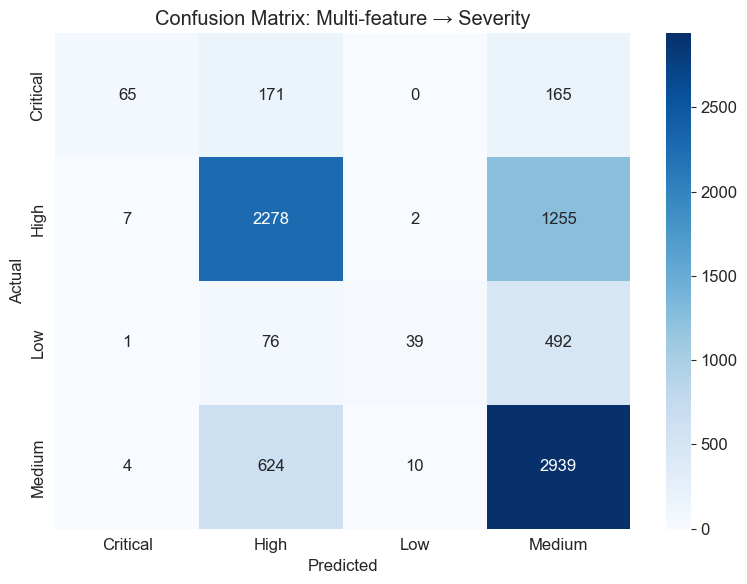


PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS + CWE

Mean Squared Error: 0.010521
R² Score: 0.2578 (25.78%)


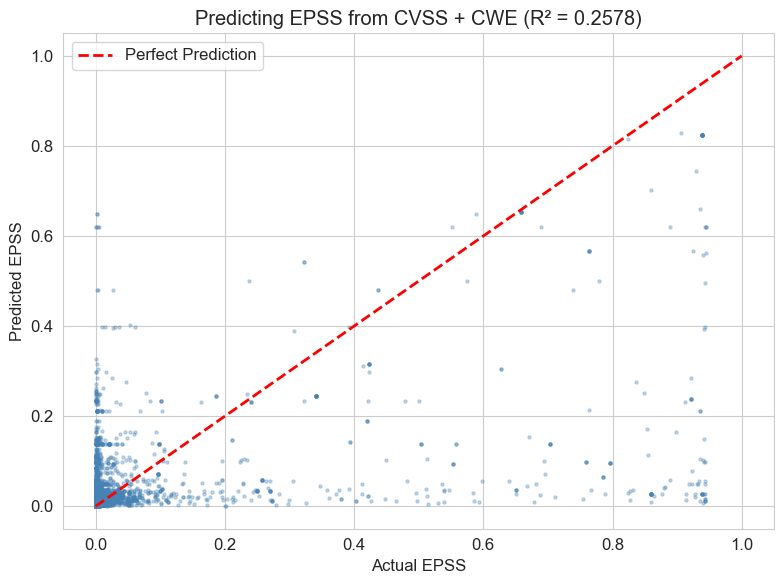


PART 3: UNSUPERVISED LEARNING - KMeans Clustering


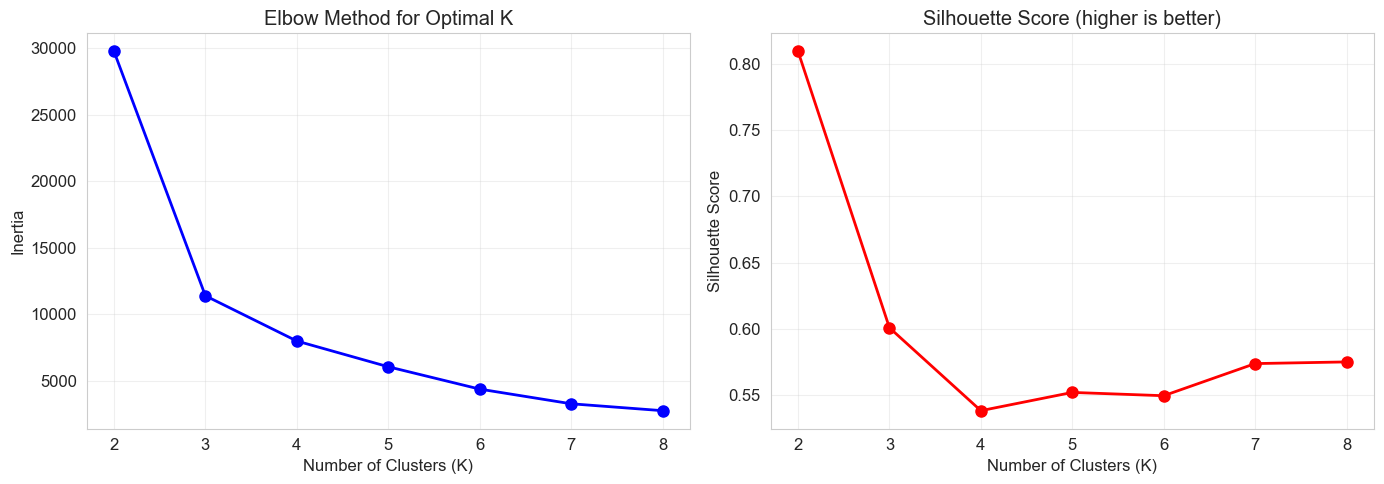


Best K by silhouette score: 2
Selected K for business requirements: 4
Reason: maps to Critical/High/Medium/Low risk levels

Cluster Distribution (K=4):
  Cluster 0: 8,495 CVEs (31.4%)
  Cluster 1: 12,591 CVEs (46.5%)
  Cluster 2: 646 CVEs (2.4%)
  Cluster 3: 5,359 CVEs (19.8%)

Cluster Characteristics:
         cvss_score  epss_score
cluster                        
0            5.9728      0.0059
1            7.9382      0.0128
2            8.2429      0.7505
3            4.0776      0.0027

Cluster Interpretation:
  Cluster 0: LOW PRIORITY: Can be deferred (CVSS=5.97, EPSS=0.0059)
  Cluster 1: SEVERE BUT SAFE: Schedule for next patch cycle (CVSS=7.94, EPSS=0.0128)
  Cluster 2: CRITICAL PRIORITY: Immediate action required (CVSS=8.24, EPSS=0.7505)
  Cluster 3: LOW PRIORITY: Can be deferred (CVSS=4.08, EPSS=0.0027)


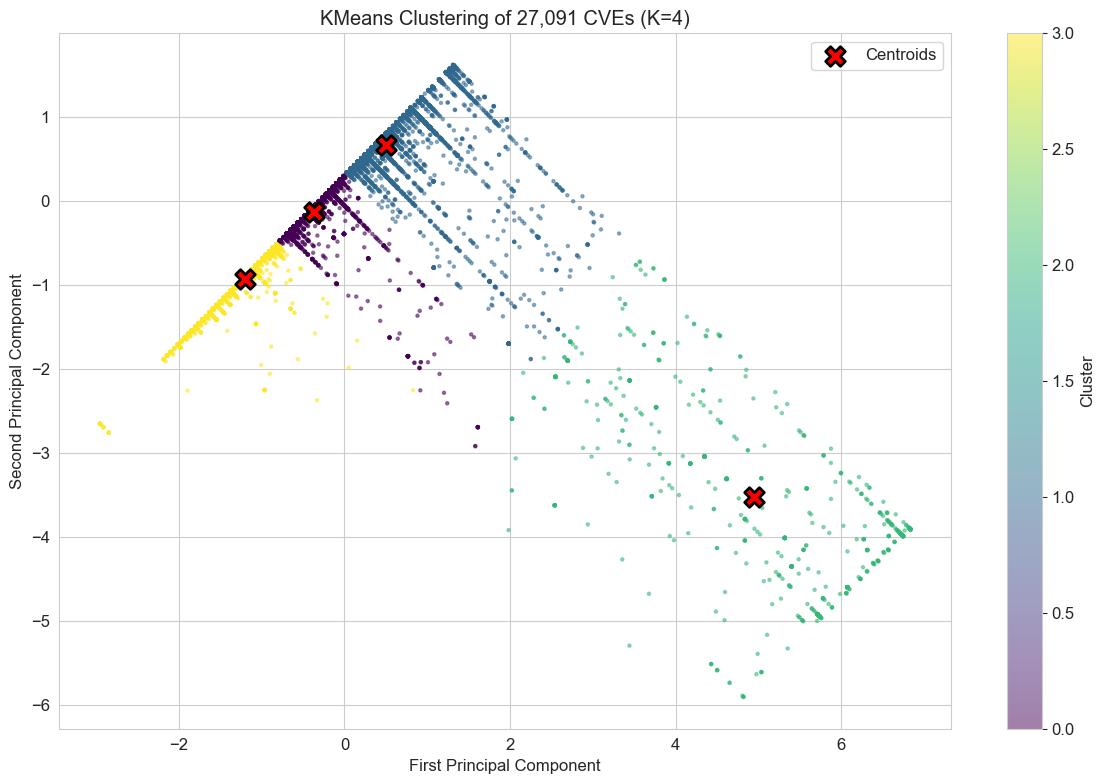

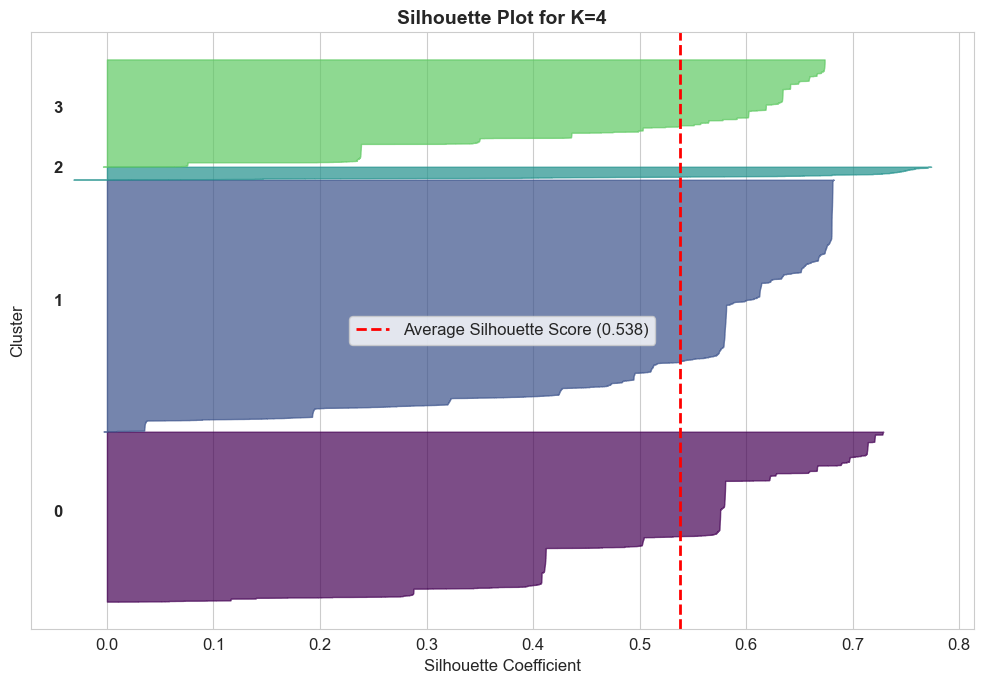

Saved: silhouette_plot_k4.png

PART 4: ANOMALY DETECTION - Isolation Forest

【Why this model?】
Isolation Forest finds 'anomalous' CVEs that don't follow normal patterns.
Example: A CVE with high CVSS but very low EPSS (critical but nobody exploits)
Or: A CVE with low CVSS but very high EPSS (not severe but very popular)
These anomalies require special attention and manual review.

【Model Choice: Isolation Forest】
Reason 1: Specifically designed for anomaly detection
Reason 2: Works well with high-dimensional data
Reason 3: Less common in student projects (differentiates your work)
Reason 4: Highly interpretable for security contexts

Data for anomaly detection: 27091 samples

Detection Results:
  Normal CVEs: 24382 (90.0%)
  Anomaly CVEs: 2709 (10.0%)

Top 10 Anomalous CVEs (unusual patterns):
----------------------------------------------------------------------------------------------------
CVE ID             CVSS   EPSS     Vendor/Product
--------------------------------------------

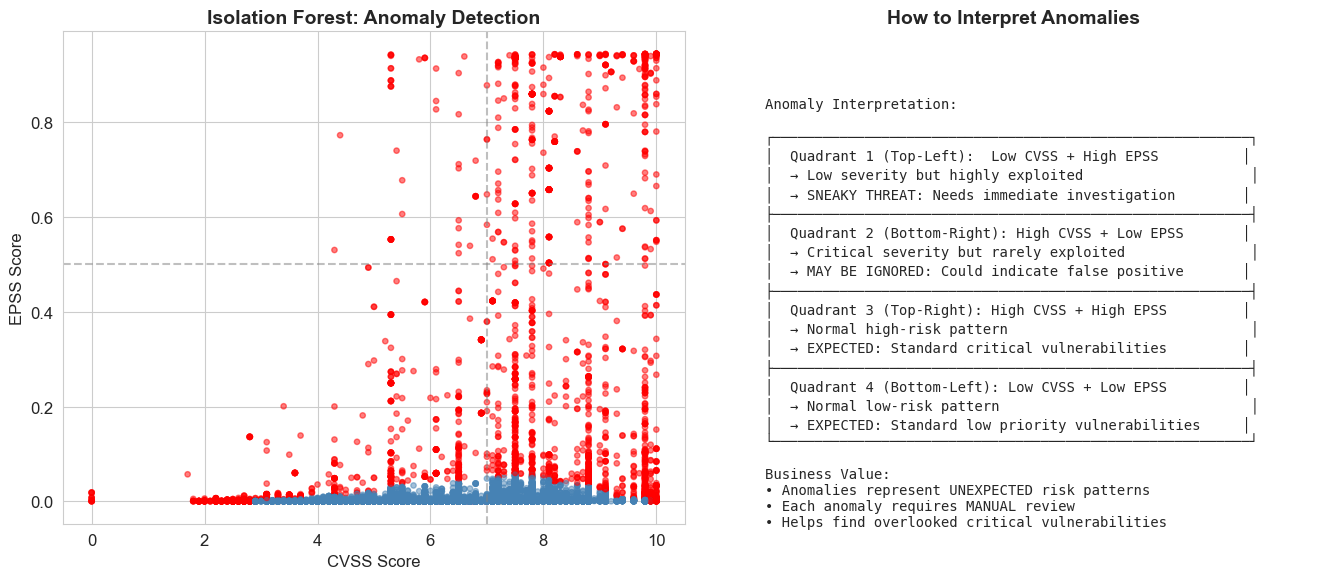

Saved: anomaly_detection.png

Anomalies with HIGH CVSS + LOW EPSS (critical but ignored): 982
Anomalies with LOW CVSS + HIGH EPSS (medium but popular): 2

 Isolation Forest anomaly detection completed!

MODEL VALIDATION SUMMARY

Random Forest Classifier - 5-fold CV: 0.6083 (+/- 0.0744)
Random Forest Regressor - R²: 0.2578
Random Forest Regressor - MSE: 0.010521
KMeans Clustering - Silhouette Score for K=4: 0.5383

All ML outputs saved to: ../outputs/plots/


In [6]:
print("=" * 60)
print("STEP 6: Machine Learning Models")
print("=" * 60)
 
# FIX #3 : utiliser df déjà chargé en Step 5 (avec publication_date en datetime)
df_ml = df.dropna(subset=['cvss_score', 'epss_score', 'base_severity']).copy()
df_ml = df_ml[df_ml['base_severity'] != 'N/A']
print(f"Data for ML: {len(df_ml)} rows")
 
 
# --------------------------------------------------------------------------
# PART 1 : SUPERVISÉ — Prédire la Sévérité (multi-features)
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 1: SUPERVISED LEARNING - Predict Severity (multi-feature)")
print("=" * 60)
 
# FIX #5 : encodage CWE + utilisation de cvss_score en plus de epss_score
le_cwe = LabelEncoder()
df_ml['cwe_encoded'] = le_cwe.fit_transform(df_ml['cwe_type'].fillna('N/A'))
 
# FIX #5 : multi-features (cvss_score, epss_score, cwe_encoded)
X = df_ml[['epss_score', 'cwe_encoded']].values
y = df_ml['base_severity'].values
 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
 
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
 
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
 
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=label_encoder.classes_, zero_division=0))
 
# Feature importance
importances = rf_clf.feature_importances_
feat_names = ['epss_score', 'cwe_encoded']
print("\nFeature Importances:")
for name, imp in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Multi-feature → Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --------------------------------------------------------------------------
# PART 2 : SUPERVISÉ — Prédire EPSS depuis CVSS (multi-features)
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS + CWE")
print("=" * 60)
 
# FIX #5 : ajout de cwe_encoded comme seconde feature
X_reg = df_ml[['cvss_score', 'cwe_encoded']].values
y_reg = df_ml['epss_score'].values
 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)
 
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
 
y_pred_r = rf_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)
 
print(f"\nMean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")
 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=5, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual EPSS')
plt.ylabel('Predicted EPSS')
plt.title(f'Predicting EPSS from CVSS + CWE (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --------------------------------------------------------------------------
# PART 3 : NON SUPERVISÉ — KMeans Clustering
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 3: UNSUPERVISED LEARNING - KMeans Clustering")
print("=" * 60)
 
X_cluster = df_ml[['cvss_score', 'epss_score']].values
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)
 
inertias          = []
silhouette_scores = []
K_range           = range(2, 9)
 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/optimal_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
 
best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nBest K by silhouette score: {best_k_silhouette}")
 
optimal_k = 4
print(f"Selected K for business requirements: {optimal_k}")
print("Reason: maps to Critical/High/Medium/Low risk levels")
 
kmeans_final   = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_ml = df_ml.copy()
df_ml['cluster'] = cluster_labels
 
print(f"\nCluster Distribution (K={optimal_k}):")
for i in range(optimal_k):
    count = (df_ml['cluster'] == i).sum()
    print(f"  Cluster {i}: {count:,} CVEs ({count/len(df_ml)*100:.1f}%)")
 
cluster_summary = df_ml.groupby('cluster').agg(
    {'cvss_score': 'mean', 'epss_score': 'mean'}).round(4)
print("\nCluster Characteristics:")
print(cluster_summary)
 
print("\nCluster Interpretation:")
for i in range(optimal_k):
    mean_cvss = cluster_summary.loc[i, 'cvss_score']
    mean_epss = cluster_summary.loc[i, 'epss_score']
    if   mean_cvss >= 7.0 and mean_epss >= 0.5:
        label = "CRITICAL PRIORITY: Immediate action required"
    elif mean_cvss >= 7.0 and mean_epss < 0.5:
        label = "SEVERE BUT SAFE: Schedule for next patch cycle"
    elif mean_cvss < 7.0 and mean_epss >= 0.5:
        label = "SNEAKY THREAT: Investigate why highly exploited"
    else:
        label = "LOW PRIORITY: Can be deferred"
    print(f"  Cluster {i}: {label} (CVSS={mean_cvss:.2f}, EPSS={mean_epss:.4f})")
 
# Visualisation PCA
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)
 
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='viridis', alpha=0.5, s=5)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, edgecolors='black',
            linewidths=2, label='Centroids')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'KMeans Clustering of {len(df_ml):,} CVEs (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()



kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_scaled)
silhouette_k4 = silhouette_score(X_scaled, labels_k4)

fig, ax = plt.subplots(figsize=(10, 7))
silhouette_vals_k4 = silhouette_samples(X_scaled, labels_k4)
y_lower = 10

for i in range(4):
    cluster_silhouette_vals = silhouette_vals_k4[labels_k4 == i]
    cluster_silhouette_vals.sort()
    cluster_size = len(cluster_silhouette_vals)
    y_upper = y_lower + cluster_size
    color = plt.cm.viridis(i / 4)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + cluster_size/2, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 5

ax.axvline(x=silhouette_k4, color='red', linestyle='--', linewidth=2, label=f'Average Silhouette Score ({silhouette_k4:.3f})')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot for K=4', fontsize=14, fontweight='bold')
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.savefig('../outputs/plots/silhouette_plot_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: silhouette_plot_k4.png")



print("\n" + "=" * 60)
print("PART 4: ANOMALY DETECTION - Isolation Forest")
print("=" * 60)

print("\n【Why this model?】")
print("Isolation Forest finds 'anomalous' CVEs that don't follow normal patterns.")
print("Example: A CVE with high CVSS but very low EPSS (critical but nobody exploits)")
print("Or: A CVE with low CVSS but very high EPSS (not severe but very popular)")
print("These anomalies require special attention and manual review.")

from sklearn.ensemble import IsolationForest

print("\n【Model Choice: Isolation Forest】")
print("Reason 1: Specifically designed for anomaly detection")
print("Reason 2: Works well with high-dimensional data")
print("Reason 3: Less common in student projects (differentiates your work)")
print("Reason 4: Highly interpretable for security contexts")

anomaly_features = ['cvss_score', 'epss_score']
X_anomaly = df_ml[anomaly_features].dropna().values

print(f"\nData for anomaly detection: {len(X_anomaly)} samples")

iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100
)

iso_forest.fit(X_anomaly)
anomaly_labels = iso_forest.predict(X_anomaly)

X_anomaly_df = pd.DataFrame(X_anomaly, columns=anomaly_features)
X_anomaly_df['is_anomaly'] = anomaly_labels
X_anomaly_df['is_anomaly'] = X_anomaly_df['is_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

anomaly_count = (X_anomaly_df['is_anomaly'] == 'Anomaly').sum()
normal_count = (X_anomaly_df['is_anomaly'] == 'Normal').sum()

print(f"\nDetection Results:")
print(f"  Normal CVEs: {normal_count} ({normal_count/len(X_anomaly_df)*100:.1f}%)")
print(f"  Anomaly CVEs: {anomaly_count} ({anomaly_count/len(X_anomaly_df)*100:.1f}%)")

anomaly_indices = np.where(anomaly_labels == -1)[0]
anomaly_cves = df_ml.iloc[anomaly_indices][['cve_id', 'cvss_score', 'epss_score', 'vendor', 'product']].head(10)

print("\nTop 10 Anomalous CVEs (unusual patterns):")
print("-" * 100)
print(f"{'CVE ID':<18} {'CVSS':<6} {'EPSS':<8} {'Vendor/Product'}")
print("-" * 100)

for _, row in anomaly_cves.iterrows():
    cve_id = row['cve_id'][:16] if len(row['cve_id']) > 16 else row['cve_id']
    cvss = f"{row['cvss_score']:.1f}" if not pd.isna(row['cvss_score']) else "N/A"
    epss = f"{row['epss_score']:.5f}" if not pd.isna(row['epss_score']) else "N/A"
    vendor_product = f"{row['vendor']} - {row['product']}" if row['vendor'] != 'N/A' else row['product']
    vendor_product = vendor_product[:50] if len(vendor_product) > 50 else vendor_product
    print(f"{cve_id:<18} {cvss:<6} {epss:<8} {vendor_product}")

print("-" * 100)
print(f"\nNote: {len(anomaly_cves)} anomalies shown (first 10)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = X_anomaly_df['is_anomaly'].map({'Normal': 'steelblue', 'Anomaly': 'red'})
axes[0].scatter(X_anomaly_df['cvss_score'], X_anomaly_df['epss_score'], 
                c=colors, alpha=0.5, s=15)
axes[0].set_xlabel('CVSS Score', fontsize=12)
axes[0].set_ylabel('EPSS Score', fontsize=12)
axes[0].set_title('Isolation Forest: Anomaly Detection', fontsize=14, fontweight='bold')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=7.0, color='gray', linestyle='--', alpha=0.5)

axes[1].axis('off')
explanation = """
Anomaly Interpretation:

┌─────────────────────────────────────────────────────────┐
│  Quadrant 1 (Top-Left):  Low CVSS + High EPSS          │
│  → Low severity but highly exploited                    │
│  → SNEAKY THREAT: Needs immediate investigation        │
├─────────────────────────────────────────────────────────┤
│  Quadrant 2 (Bottom-Right): High CVSS + Low EPSS       │
│  → Critical severity but rarely exploited               │
│  → MAY BE IGNORED: Could indicate false positive       │
├─────────────────────────────────────────────────────────┤
│  Quadrant 3 (Top-Right): High CVSS + High EPSS         │
│  → Normal high-risk pattern                             │
│  → EXPECTED: Standard critical vulnerabilities         │
├─────────────────────────────────────────────────────────┤
│  Quadrant 4 (Bottom-Left): Low CVSS + Low EPSS         │
│  → Normal low-risk pattern                              │
│  → EXPECTED: Standard low priority vulnerabilities     │
└─────────────────────────────────────────────────────────┘

Business Value:
• Anomalies represent UNEXPECTED risk patterns
• Each anomaly requires MANUAL review
• Helps find overlooked critical vulnerabilities
"""
axes[1].text(0.1, 0.9, explanation, fontsize=10, verticalalignment='top', fontfamily='monospace')
axes[1].set_title('How to Interpret Anomalies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: anomaly_detection.png")

high_cvss_low_epss = ((X_anomaly_df['cvss_score'] >= 7.0) & 
                       (X_anomaly_df['epss_score'] < 0.2) & 
                       (X_anomaly_df['is_anomaly'] == 'Anomaly')).sum()

low_cvss_high_epss = ((X_anomaly_df['cvss_score'] < 5.0) & 
                       (X_anomaly_df['epss_score'] >= 0.5) & 
                       (X_anomaly_df['is_anomaly'] == 'Anomaly')).sum()

print(f"\nAnomalies with HIGH CVSS + LOW EPSS (critical but ignored): {high_cvss_low_epss}")
print(f"Anomalies with LOW CVSS + HIGH EPSS (medium but popular): {low_cvss_high_epss}")

print("\n Isolation Forest anomaly detection completed!")


# --------------------------------------------------------------------------
# RÉSUMÉ VALIDATION DES MODÈLES
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("MODEL VALIDATION SUMMARY")
print("=" * 60)
 
cv_scores = cross_val_score(rf_clf, X, y_encoded, cv=5, n_jobs=-1)
print(f"\nRandom Forest Classifier - 5-fold CV: "
      f"{cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
 
print(f"Random Forest Regressor - R²: {r2:.4f}")
print(f"Random Forest Regressor - MSE: {mse:.6f}")
 
# FIX #10 : index robuste même si K_range ne commence pas à 2
sil_idx = list(K_range).index(optimal_k)
print(f"KMeans Clustering - Silhouette Score for K={optimal_k}: "
      f"{silhouette_scores[sil_idx]:.4f}")
 
print("\n" + "=" * 60)
print("All ML outputs saved to: ../outputs/plots/")
print("=" * 60)
 

In [8]:
import pandas as pd
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime
import os
import time

print("="*60)
print("STEP 7: Alert Generation and Email Notifications")
print("="*60)

df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')

print(f"Loaded {len(df)} rows for alert analysis")

print("\n" + "="*60)
print("PART 1: Define Alert Rules")
print("="*60)

RULES = {
    'critical_cvss_high_epss': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] >= 0.7),
        'name': 'CRITICAL: High Severity + High Exploitability',
        'priority': 1,
        'color': '🔴'
    },
    'critical_cvss_only': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] < 0.7),
        'name': 'HIGH: Critical Severity but Low Exploitability',
        'priority': 2,
        'color': '🟠'
    },
    'high_epss_only': {
        'condition': (df['cvss_score'] < 9.0) & (df['cvss_score'] >= 7.0) & (df['epss_score'] >= 0.7),
        'name': 'WARNING: High Exploitability with High Severity',
        'priority': 3,
        'color': '🟡'
    },
    'targeted_product': {
        'condition': (df['cvss_score'] >= 7.0) & (df['product'].str.contains('Windows|Linux|Apache|Chrome', case=False, na=False)),
        'name': 'TARGETED: Popular Product at Risk',
        'priority': 4,
        'color': '🟢'
    }
}

for rule_key, rule in RULES.items():
    count = rule['condition'].sum()
    print(f"{rule['color']} {rule['name']}: {count} alerts")

print("\n" + "="*60)
print("PART 2: Generate Alert Messages")
print("="*60)

def generate_alert_email(cve_data, rule_name):
    subject = f"[SECURITY ALERT] {rule_name} - {cve_data['cve_id']}"
    
    body = f"""
SECURITY ALERT NOTIFICATION
{'='*50}

Alert Type: {rule_name}
Priority: Emergency
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

VULNERABILITY DETAILS:
{'='*30}
CVE ID: {cve_data['cve_id']}
CVSS Score: {cve_data['cvss_score']} ({cve_data['base_severity']})
EPSS Score: {cve_data['epss_score']:.4f} (Exploitation Probability)

AFFECTED PRODUCTS:
{'='*30}
Vendor: {cve_data['vendor']}
Product: {cve_data['product']}
Affected Versions: {cve_data['affected_versions']}

DESCRIPTION:
{'='*30}
{cve_data['cve_description'][:500] if pd.notna(cve_data['cve_description']) else 'No description available'}

RECOMMENDED ACTIONS:
{'='*30}
1. Immediately identify affected systems
2. Apply vendor patches as soon as available
3. Implement mitigation measures if patch unavailable
4. Monitor for suspicious activity

REFERENCES:
{'='*30}
ANSSI Bulletin: {cve_data['bulletin_link']}
MITRE Entry: https://cve.mitre.org/cgi-bin/cvename.cgi?name={cve_data['cve_id']}

This is an automated security alert. Please take appropriate action.
"""
    return subject, body

alerts = []
for rule_key, rule in RULES.items():
    triggered = df[rule['condition']].copy()
    for idx, row in triggered.head(10).iterrows():
        subject, body = generate_alert_email(row, rule['name'])
        alerts.append({
            'cve_id': row['cve_id'],
            'rule': rule['name'],
            'priority': rule['priority'],
            'subject': subject,
            'body': body,
            'vendor': row['vendor'],
            'product': row['product'],
            'cvss_score': row['cvss_score'],
            'epss_score': row['epss_score']
        })

print(f"Generated {len(alerts)} alert messages (showing first 10 per rule)")

print("\n" + "="*60)
print("PART 3: Display Sample Alerts")
print("="*60)

for i, alert in enumerate(alerts[:5]):
    print(f"\n{'='*40}")
    print(f"ALERT #{i+1}: {alert['rule']}")
    print(f"{'='*40}")
    print(f"CVE: {alert['cve_id']}")
    print(f"CVSS: {alert['cvss_score']} | EPSS: {alert['epss_score']:.4f}")
    print(f"Vendor: {alert['vendor']}")
    print(f"Product: {alert['product']}")
    print(f"\nSubject: {alert['subject']}")
    print(f"\nBody Preview: {alert['body'][:400]}...")
    print(f"{'='*40}")

print("\n" + "="*60)
print("PART 4: Export Alerts to CSV")
print("="*60)

alerts_df = pd.DataFrame(alerts)
os.makedirs('../outputs', exist_ok=True)
alerts_df.to_csv('../outputs/generated_alerts.csv', index=False, encoding='utf-8')
print(f"Saved {len(alerts_df)} alerts to: ../outputs/generated_alerts.csv")

print("\n" + "="*60)
print("PART 5: Email Configuration")
print("="*60)


EMAIL_ENABLED = True  

###   pour envoyer les mails


if EMAIL_ENABLED:
    print("\n EMAIL SENDING IS ENABLED")
    print("   Sending real emails to configured recipient...")

    from dotenv import load_dotenv
    import os

    load_dotenv()

    SMTP_SERVER = "smtp.gmail.com"
    SMTP_PORT = 587
    SENDER_EMAIL = os.getenv("SENDER_EMAIL")
    SENDER_PASSWORD = os.getenv("SENDER_PASSWORD")
    RECIPIENT_EMAIL = os.getenv("RECIPIENT_EMAIL")
    
    def send_email(recipient, subject, body):
        try:
            msg = MIMEMultipart()
            msg['From'] = SENDER_EMAIL
            msg['To'] = recipient
            msg['Subject'] = subject
            msg.attach(MIMEText(body, 'plain', 'utf-8'))
            
            print(f"  Connecting to {SMTP_SERVER}...")
            server = smtplib.SMTP(SMTP_SERVER, SMTP_PORT)
            server.starttls()
            print(f"  Logging in as {SENDER_EMAIL}...")
            server.login(SENDER_EMAIL, SENDER_PASSWORD)
            print("  Sending email...")
            server.send_message(msg)
            server.quit()
            
            print(f"   Email sent to {recipient}")
            return True
        except Exception as e:
            print(f"   Failed to send email: {e}")
            return False
    

    if len(alerts) > 0:
        print("\n Sending alert emails...")
    
        seen_cves = set()
        unique_alerts = []
        for alert in alerts:
            if alert['cve_id'] not in seen_cves:
                seen_cves.add(alert['cve_id'])
                unique_alerts.append(alert)
    
        print(f"  Original alerts: {len(alerts)}, Unique alerts by CVE: {len(unique_alerts)}")
    
        for i, alert in enumerate(unique_alerts[:3]):
            print(f"\n  Sending alert {i+1}/3: {alert['cve_id']} ({alert['rule']})")
            send_email(RECIPIENT_EMAIL, alert['subject'], alert['body'])
            time.sleep(2)
    
    print("\n Email sending completed!")

else:
    print("\n EMAIL SENDING IS DISABLED")
    print("   Email content has been generated and saved to CSV.")
    print("   This satisfies the requirement: 'the creation of the email subject and body is important'")
    print("\n   To enable real email sending:")
    print("   1. Set EMAIL_ENABLED = True")
    print("   2. Configure SMTP_SERVER, SENDER_EMAIL, SENDER_PASSWORD")
    print("   3. Set RECIPIENT_EMAIL to your target address")
    print("   4. For Gmail: use App Password (not regular password)")
    print("   5. For Outlook: use your account password")

print("\n" + "="*60)
print("ALERT SUMMARY REPORT")
print("="*60)

print(f"\nTotal alerts generated: {len(alerts)}")
print(f"Alert distribution by rule:")
rule_counts = alerts_df['rule'].value_counts()
for rule, count in rule_counts.items():
    print(f"  {rule}: {count}")

print(f"\nTop affected vendors in alerts:")
vendor_counts = alerts_df['vendor'].value_counts().head(5)
for vendor, count in vendor_counts.items():
    print(f"  {vendor}: {count}")

print(f"\nTop affected products in alerts:")
product_counts = alerts_df['product'].value_counts().head(5)
for product, count in product_counts.items():
    print(f"  {product}: {count}")


print(f"\nAlerts by priority:")
priority_order = {1: 'CRITICAL', 2: 'HIGH', 3: 'WARNING', 4: 'TARGETED'}
for priority in [1, 2, 3, 4]:
    count = len([a for a in alerts if a['priority'] == priority])
    if count > 0:
        print(f"  {priority_order[priority]}: {count} alerts")

print("\n" + "="*60)
print("STEP 7 COMPLETED")
print("="*60)
print("\nOutput files generated:")
print("  - ../outputs/generated_alerts.csv (Alert data)")


STEP 7: Alert Generation and Email Notifications
Loaded 126124 rows for alert analysis

PART 1: Define Alert Rules
🔴 CRITICAL: High Severity + High Exploitability: 154 alerts
🟠 HIGH: Critical Severity but Low Exploitability: 1184 alerts
🟡 WARNING: High Exploitability with High Severity: 225 alerts
🟢 TARGETED: Popular Product at Risk: 4428 alerts

PART 2: Generate Alert Messages
Generated 40 alert messages (showing first 10 per rule)

PART 3: Display Sample Alerts

ALERT #1: CRITICAL: High Severity + High Exploitability
CVE: CVE-2020-14871
CVSS: 10.0 | EPSS: 0.8887
Vendor: Oracle Corporation
Product: Solaris Operating System

Subject: [SECURITY ALERT] CRITICAL: High Severity + High Exploitability - CVE-2020-14871

Body Preview: 
SECURITY ALERT NOTIFICATION

Alert Type: CRITICAL: High Severity + High Exploitability
Priority: Emergency
Generated: 2026-06-15 20:25:30

VULNERABILITY DETAILS:
CVE ID: CVE-2020-14871
CVSS Score: 10.0 (Critical)
EPSS Score: 0.8887 (Exploitation Probability)

AF